In [3]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU")

CUDA available: True
GPU: Tesla T4


In [2]:
!unzip -q data.zip
print("Done unzipping")

replace __MACOSX/._data? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C
Done unzipping


In [4]:
!find data -type d

data
data/training
data/training/03-severe
data/training/01-minor
data/training/02-moderate
data/validation
data/validation/03-severe
data/validation/01-minor
data/validation/02-moderate


In [5]:
import os

for split in ["training", "validation"]:
    print(f"\n{split}:")
    split_path = os.path.join("data", split)
    for cls in sorted(os.listdir(split_path)):
        cls_path = os.path.join(split_path, cls)
        if os.path.isdir(cls_path):
            n = len([f for f in os.listdir(cls_path)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            print(f"  {cls}: {n} images")


training:
  01-minor: 452 images
  02-moderate: 463 images
  03-severe: 468 images

validation:
  01-minor: 82 images
  02-moderate: 75 images
  03-severe: 91 images


In [6]:
from datasets import load_dataset, DatasetDict

# Load the pre-split folders directly
train_ds = load_dataset("imagefolder", data_dir="data/training", split="train")
val_ds   = load_dataset("imagefolder", data_dir="data/validation", split="train")

# Auto-detected labels (from the folder names)
labels = train_ds.features["label"].names
print(f"{len(labels)} classes: {labels}")
print(f"Train images: {len(train_ds)}")
print(f"Val images:   {len(val_ds)}")

Resolving data files:   0%|          | 0/1383 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/248 [00:00<?, ?it/s]

3 classes: ['01-minor', '02-moderate', '03-severe']
Train images: 1383
Val images:   248


In [7]:
from datasets import DatasetDict

# Split the 248 validation images into validation + test (50/50, seed=42)
val_test = val_ds.train_test_split(test_size=0.5, seed=42)

dataset = DatasetDict({
    "train":      train_ds,
    "validation": val_test["train"],
    "test":       val_test["test"],
})

print(dataset)
print(f"\nTrain: {len(dataset['train'])}")
print(f"Val:   {len(dataset['validation'])}")
print(f"Test:  {len(dataset['test'])}")

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 1383
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 124
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 124
    })
})

Train: 1383
Val:   124
Test:  124


In [8]:
label2id = {label: idx for idx, label in enumerate(labels)}
id2label = {idx: label for idx, label in enumerate(labels)}
print("label2id:", label2id)
print("id2label:", id2label)

label2id: {'01-minor': 0, '02-moderate': 1, '03-severe': 2}
id2label: {0: '01-minor', 1: '02-moderate', 2: '03-severe'}


In [9]:
from transformers import AutoImageProcessor
from torchvision.transforms import (
    Compose, RandomHorizontalFlip, ColorJitter,
    RandomResizedCrop, Resize, CenterCrop, ToTensor, Normalize
)

processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224")

# Normalization values + target size from the pretrained processor
normalize = Normalize(mean=processor.image_mean, std=processor.image_std)
size = processor.size["height"]   # 224

# TRAIN: damage-safe augmentation
train_transforms = Compose([
    RandomResizedCrop(size, scale=(0.85, 1.0)),   # mild zoom/crop, keeps damage in frame
    RandomHorizontalFlip(p=0.5),                   # safe: a dent is still a dent mirrored
    ColorJitter(brightness=0.2, contrast=0.2),     # mild lighting variation only
    ToTensor(),
    normalize,
])

# VALIDATION / TEST: clean, no augmentation
eval_transforms = Compose([
    Resize(size),
    CenterCrop(size),
    ToTensor(),
    normalize,
])

def apply_train_transforms(batch):
    batch["pixel_values"] = [train_transforms(img.convert("RGB")) for img in batch["image"]]
    return batch

def apply_eval_transforms(batch):
    batch["pixel_values"] = [eval_transforms(img.convert("RGB")) for img in batch["image"]]
    return batch

# Attach transforms: augment train, keep val/test clean
dataset["train"].set_transform(apply_train_transforms)
dataset["validation"].set_transform(apply_eval_transforms)
dataset["test"].set_transform(apply_eval_transforms)

print("Transforms attached.")
print("Image size:", size)
print("Normalize mean:", processor.image_mean, "| std:", processor.image_std)

Transforms attached.
Image size: 224
Normalize mean: (0.5, 0.5, 0.5) | std: (0.5, 0.5, 0.5)


In [10]:
import torch
import numpy as np
import evaluate

# ── Collator: stack the batch into tensors ──
def collate_fn(batch):
    return {
        "pixel_values": torch.stack([x["pixel_values"] for x in batch]),
        "labels": torch.tensor([x["label"] for x in batch]),
    }

# ── Metrics: accuracy + macro precision/recall/F1 ──
accuracy  = evaluate.load("accuracy")
precision = evaluate.load("precision")
recall    = evaluate.load("recall")
f1        = evaluate.load("f1")

def compute_metrics(eval_preds):
    logits, labels = eval_preds
    predictions = np.argmax(logits, axis=1)
    return {
        "accuracy":  accuracy.compute(predictions=predictions, references=labels)["accuracy"],
        "precision": precision.compute(predictions=predictions, references=labels, average="macro")["precision"],
        "recall":    recall.compute(predictions=predictions, references=labels, average="macro")["recall"],
        "f1":        f1.compute(predictions=predictions, references=labels, average="macro")["f1"],
    }

print("Collator and metrics ready.")

Collator and metrics ready.


In [11]:
from transformers import ViTForImageClassification

model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

for name, p in model.named_parameters():
    if not name.startswith("classifier"):
        p.requires_grad = False

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params:     {total:,}")
print(f"Trainable params: {trainable:,}  ({trainable/total*100:.3f}%)")

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 768]) vs model:torch.Size([3, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([3])          

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Total params:     85,800,963
Trainable params: 2,307  (0.003%)


In [12]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./car-damage-vit",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=8,
    learning_rate=3e-4,
    save_strategy="epoch",
    eval_strategy="epoch",
    logging_steps=20,
    save_total_limit=2,
    remove_unused_columns=False,
    push_to_hub=False,                 # manual upload, like your plant project
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    seed=42,
)

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    processing_class=processor,
)

print("Trainer ready. Output dir:", training_args.output_dir)

Trainer ready. Output dir: ./car-damage-vit


In [13]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.851099,0.751346,0.669355,0.688619,0.666902,0.668447
2,0.779900,0.669274,0.733871,0.722510,0.720989,0.719904
3,0.755127,0.647639,0.733871,0.721296,0.717098,0.713087
4,0.699629,0.642468,0.725806,0.718225,0.714852,0.712227
5,0.703340,0.625711,0.733871,0.722890,0.721796,0.719821
6,0.700308,0.620042,0.717742,0.702937,0.701594,0.699122
7,0.700082,0.625562,0.733871,0.724320,0.721796,0.719542
8,0.692510,0.624735,0.725806,0.712724,0.711695,0.709393


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['vit.layers.0.attention.q_proj.weight', 'vit.layers.0.attention.q_proj.bias', 'vit.layers.0.attention.k_proj.weight', 'vit.layers.0.attention.k_proj.bias', 'vit.layers.0.attention.v_proj.weight', 'vit.layers.0.attention.v_proj.bias', 'vit.layers.0.attention.o_proj.weight', 'vit.layers.0.attention.o_proj.bias', 'vit.layers.0.layernorm_before.weight', 'vit.layers.0.layernorm_before.bias', 'vit.layers.0.layernorm_after.weight', 'vit.layers.0.layernorm_after.bias', 'vit.layers.0.mlp.fc1.weight', 'vit.layers.0.mlp.fc1.bias', 'vit.layers.0.mlp.fc2.weight', 'vit.layers.0.mlp.fc2.bias', 'vit.layers.1.attention.q_proj.weight', 'vit.layers.1.attention.q_proj.bias', 'vit.layers.1.attention.k_proj.weight', 'vit.layers.1.attention.k_proj.bias', 'vit.layers.1.attention.v_proj.weight', 'vit.layers.1.attention.v_proj.bias', 'vit.layers.1.attention.o_proj.weight', 'vit.layers.1.attention.o_proj.bias', 'vit.layers.1.layernorm_before

TrainOutput(global_step=696, training_loss=0.7344170466236685, metrics={'train_runtime': 181.3887, 'train_samples_per_second': 60.996, 'train_steps_per_second': 3.837, 'total_flos': 8.573790574442742e+17, 'train_loss': 0.7344170466236685, 'epoch': 8.0})

=== TEST SET METRICS (touched once) ===
{'test_loss': 0.7096312046051025, 'test_accuracy': 0.6854838709677419, 'test_precision': 0.6803007245336473, 'test_recall': 0.6858477439872789, 'test_f1': 0.6821225071225072, 'test_runtime': 1.6021, 'test_samples_per_second': 77.4, 'test_steps_per_second': 4.994}

=== Per-Class Report ===
              precision    recall  f1-score   support

    01-minor      0.744     0.744     0.744        39
 02-moderate      0.553     0.500     0.525        42
   03-severe      0.745     0.814     0.778        43

    accuracy                          0.685       124
   macro avg      0.680     0.686     0.682       124
weighted avg      0.679     0.685     0.681       124



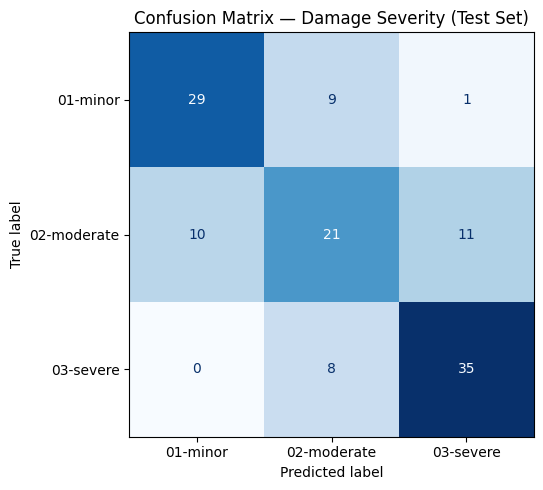

In [14]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict on the held-out TEST set (touched once)
pred_output = trainer.predict(dataset["test"])
y_true = pred_output.label_ids
y_pred = np.argmax(pred_output.predictions, axis=1)

# Overall test metrics
print("=== TEST SET METRICS (touched once) ===")
print(pred_output.metrics)

# Per-class precision / recall / F1
print("\n=== Per-Class Report ===")
print(classification_report(y_true, y_pred, target_names=labels, digits=3))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix — Damage Severity (Test Set)")
plt.tight_layout()
plt.show()

In [15]:
output_dir = training_args.output_dir   # "./car-damage-vit"

trainer.save_model(output_dir)          # saves the best (epoch-5) model
processor.save_pretrained(output_dir)   # saves the preprocessing config

print("Saved to:", output_dir)

# Confirm the files are there
import os
for f in sorted(os.listdir(output_dir)):
    print("  ", f)

# Print labels 
print("\nLabel order (for the app):", labels)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to: ./car-damage-vit
   checkpoint-174
   checkpoint-696
   config.json
   model.safetensors
   preprocessor_config.json
   training_args.bin

Label order (for the app): ['01-minor', '02-moderate', '03-severe']
